# Physiological Signals and Head Motion at Respiratory Events

## Load Data

In [1]:
# misc directory is at the same level as scan directory, 
# so we need to change the current working directory to the root directory
# ONLY RUN THIS CELL ONCE
import os

os.chdir(os.path.dirname(os.getcwd()))

In [ ]:
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

from scan.io.load import DatasetLoad

# load all phsyio siginals in dataset and concatenate
loader = DatasetLoad(
    'vanderbilt'
)

# load func data
data_func, _ = loader.load(
    data_type='func',
    func_high_pass=True,
    verbose=False,
    norm='zscore'
)

# load physio data
data_physio, _ = loader.load(
    data_type='physio',
    physio_high_pass=True,
    resample_physio=False,
    verbose=False,
    norm='robust_z'
)

# load physio data without norm (for head motion)
data_physio_nonnorm, _ = loader.load(
    data_type='physio',
    norm=None,
    verbose=False
)


260930-21:22:57,528 nipype.utils WARNING:
	 A newer version (1.11.0) of nipy/nipype is available. You are using 1.8.6


/Users/tbolt/Desktop/Research/SCAN/scan_physio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare Physio Signals for Plotting

In [3]:
# create signal dictionary for each signal type
EMG_SIGNAL_NAMES = ['emg1_hf_amp', 'emg2_hf_amp', 'emg3_hf_amp']
EOG_SIGNAL_NAMES = ['eog1_hf_amp', 'eog2_hf_amp']
RESP_SIGNAL_NAMES = ['resp_amp', 'resp_if']
HEAD_MOTION_SIGNAL_NAMES = ['pitch', 'roll', 'yaw', 'trans_x', 'trans_y', 'trans_z']
data_out = {}

# create averaged EMG signals
data_out['emg_avg'] = [
    np.mean([data_physio.physio[emg_name][i] for emg_name in EMG_SIGNAL_NAMES], axis=0)
    for i in range(len(data_physio.physio[EMG_SIGNAL_NAMES[0]]))
]
data_out['eog_avg'] = [
    np.mean([data_physio.physio[eog_name][i] for eog_name in EOG_SIGNAL_NAMES], axis=0)
    for i in range(len(data_physio.physio[EOG_SIGNAL_NAMES[0]]))
]
for resp_name in RESP_SIGNAL_NAMES:
    data_out[resp_name] = [
        data_physio.physio[resp_name][i]
        for i in range(len(data_physio.physio[resp_name]))
    ]
for motion_name in HEAD_MOTION_SIGNAL_NAMES:
    data_out[motion_name] = [
        data_physio_nonnorm.physio[motion_name][i]
        for i in range(len(data_physio_nonnorm.physio[motion_name]))
    ]

# get global signal
data_out['global_signal'] = [
    func.mean(axis=1)
    for func in data_func.func
]

## Bootstrap Event Averages

In [ ]:
EVENT_DUR = 20.0
EVENT_DT = 0.1
EVENT_TIME = np.arange(0.0, EVENT_DUR + EVENT_DT / 2.0, EVENT_DT)

signal_groups = [
    (
        "Respiratory / EOG / EMG",
        [
            ("Resp. amplitude", data_out["resp_amp"], 10.0, "#1b9e77"),
            ("Resp. instantaneous freq", data_out["resp_if"], 10.0, "#d95f02"),
            ("EOG mean", data_out["eog_avg"], 10.0, "#7570b3"),
            ("EMG mean", data_out["emg_avg"], 10.0, "#e7298a"),
        ],
    ),
    (
        "Head motion",
        [
            ("Pitch", data_out["pitch"], 1 / 2.1, "#4c78a8"),
            ("Roll", data_out["roll"], 1 / 2.1, "#f58518"),
            ("Yaw", data_out["yaw"], 1 / 2.1, "#54a24b"),
            ("Trans X", data_out["trans_x"], 1 / 2.1, "#e45756"),
            ("Trans Y", data_out["trans_y"], 1 / 2.1, "#72b7b2"),
            ("Trans Z", data_out["trans_z"], 1 / 2.1, "#b279a2"),
        ],
    ),
    (
        "Global fMRI signal",
        [
            ("Global signal", data_out["global_signal"], 1 / 2.1, "#66c2a5"),
        ],
    )
]


def _generate_bootstrap_samples(
    subject_session_list: list[tuple[str, str]], n_bootstrap: int = 1000
) -> list[list[tuple[str, str]]]:
    """
    Generate bootstrap samples at the subject level.

    This function takes a list of (subject, session) tuples and generates
    repeated samples with replacement of subjects. Multiple sessions per subject
    are preserved in the bootstrap samples.

    Parameters
    ----------
    subject_session_list : List[Tuple[str, str]]
        List of (subject, session) tuples
    n_bootstrap : int, optional
        Number of bootstrap samples to generate (default: 1000)

    Returns
    -------
    List[List[Tuple[str, str]]]
        List of bootstrap samples, where each sample is a list of
        (subject, session) tuples
    """
    # Group sessions by subject
    subject_sessions = defaultdict(list)
    for subject, session in subject_session_list:
        subject_sessions[subject].append(session)

    # Get unique subjects
    unique_subjects = list(subject_sessions.keys())
    n_subjects = len(unique_subjects)

    bootstrap_samples = []

    for _ in range(n_bootstrap):
        # Sample subjects with replacement
        sampled_subjects = random.choices(unique_subjects, k=n_subjects)

        # Create bootstrap sample by including all sessions for each sampled subject
        bootstrap_sample = []
        for subject in sampled_subjects:
            for session in subject_sessions[subject]:
                bootstrap_sample.append((subject, session))

        bootstrap_samples.append(bootstrap_sample)

    return bootstrap_samples


def bootstrap_iter(signal_group_iter, scan_events, bootstrap_idx):
    # Initialize the output dictionary for this bootstrap iteration
    iter_out = {
        group_label: {
            signal_label: [] for signal_label, _, _, _ in specs
        } for group_label, specs in signal_group_iter
    }
    # get the scan events corresponding to the current bootstrap indices
    scan_events_iter = [scan_events[idx] for idx in bootstrap_idx]
    for group_label, specs in signal_group_iter:
        for signal_label, scan_series, sampling_rate, _ in specs:
            # get the scan series aligned with the current bootstrap indices
            scan_series_iter = [scan_series[idx] for idx in bootstrap_idx]
            # Extract event-aligned windows for the current signal
            windows = _extract_event_windows(
                scan_series=scan_series_iter,
                scan_events=scan_events_iter,
                sampling_rate=sampling_rate,
                event_time=EVENT_TIME,
            )
            if windows.size == 0:
                continue

            mean_window = _nanmean_axis0(windows)
            iter_out[group_label][signal_label].append(mean_window)

    return iter_out


def _extract_event_windows(
    scan_series: list[np.ndarray],
    scan_events: list[list[float]],
    sampling_rate: float,
    event_time: np.ndarray,
) -> np.ndarray:
    windows: list[np.ndarray] = []

    for signal, onsets in zip(scan_series, scan_events):
        signal_1d = _as_1d(signal)
        if signal_1d.size < 2:
            continue

        finite_mask = np.isfinite(signal_1d)
        if finite_mask.sum() < 2:
            continue

        signal_time = np.arange(signal_1d.size, dtype=float) / float(sampling_rate)
        signal_time = signal_time[finite_mask]
        signal_values = signal_1d[finite_mask]

        for onset in np.atleast_1d(onsets):
            if not np.isfinite(onset):
                continue
            aligned_time = float(onset) + event_time
            window = np.interp(
                aligned_time,
                signal_time,
                signal_values,
                left=np.nan,
                right=np.nan,
            )
            windows.append(window)

    if not windows:
        return np.empty((0, event_time.size), dtype=float)

    return np.vstack(windows)


def _nanmean_axis0(values: np.ndarray) -> np.ndarray:
    if values.size == 0:
        return np.array([])

    finite_mask = np.isfinite(values)
    counts = finite_mask.sum(axis=0)
    summed = np.nansum(values, axis=0)
    return np.divide(
        summed,
        counts,
        out=np.full(values.shape[1], np.nan, dtype=float),
        where=counts > 0,
    )

def _as_1d(signal: np.ndarray) -> np.ndarray:
    array = np.asarray(signal).squeeze()
    return array.reshape(-1)


subject_session_list = list(loader.iter)

# filter out any sessions with no events
subject_session_list_sigh_event = [
    (subject, session)
    for (subject, session), event_list in zip(subject_session_list, data_physio.breath_events)
    if len(event_list) > 0
]
subject_session_list_yawn_event = [
    (subject, session)
    for (subject, session), event_list in zip(subject_session_list, data_physio.yawn_events)
    if len(event_list) > 0
]

bootstrap_samples_sigh = _generate_bootstrap_samples(subject_session_list_sigh_event)
bootstrap_samples_yawn = _generate_bootstrap_samples(subject_session_list_yawn_event)

bootstrap_results_sigh = []
bootstrap_results_yawn = []
print(f'Number of bootstrap samples for sigh events: {len(bootstrap_samples_sigh)}')
for i, sample in enumerate(bootstrap_samples_sigh):
    if i % 100 == 0:
        print(f'Processing bootstrap sample {i + 1}/{len(bootstrap_samples_sigh)}')
    # get indices of bootstrap samples
    bootstrap_indices = [
        subject_session_list.index((subject, session))
        for subject, session in sample
    ]
    iter_out = bootstrap_iter(
        signal_groups, data_physio.breath_events, bootstrap_indices
    )
    bootstrap_results_sigh.append(iter_out)
    

print(f'Number of bootstrap samples for yawn events: {len(bootstrap_samples_yawn)}')
for i, sample in enumerate(bootstrap_samples_yawn):
    if i % 100 == 0:
        print(f'Processing bootstrap sample {i + 1}/{len(bootstrap_samples_yawn)}')
    # process each bootstrap sample for yawn events
    bootstrap_indices = [
        subject_session_list.index((subject, session))
        for subject, session in sample
    ]
    iter_out = bootstrap_iter(
        signal_groups, data_physio.yawn_events, bootstrap_indices
    )
    bootstrap_results_yawn.append(iter_out)

Number of bootstrap samples for sigh events: 1000
Processing bootstrap sample 1/1000
Processing bootstrap sample 101/1000
Processing bootstrap sample 201/1000
Processing bootstrap sample 301/1000
Processing bootstrap sample 401/1000
Processing bootstrap sample 501/1000
Processing bootstrap sample 601/1000
Processing bootstrap sample 701/1000
Processing bootstrap sample 801/1000
Processing bootstrap sample 901/1000
Number of bootstrap samples for yawn events: 1000
Processing bootstrap sample 1/1000
Processing bootstrap sample 101/1000
Processing bootstrap sample 201/1000
Processing bootstrap sample 301/1000
Processing bootstrap sample 401/1000
Processing bootstrap sample 501/1000
Processing bootstrap sample 601/1000
Processing bootstrap sample 701/1000
Processing bootstrap sample 801/1000
Processing bootstrap sample 901/1000


## Plot

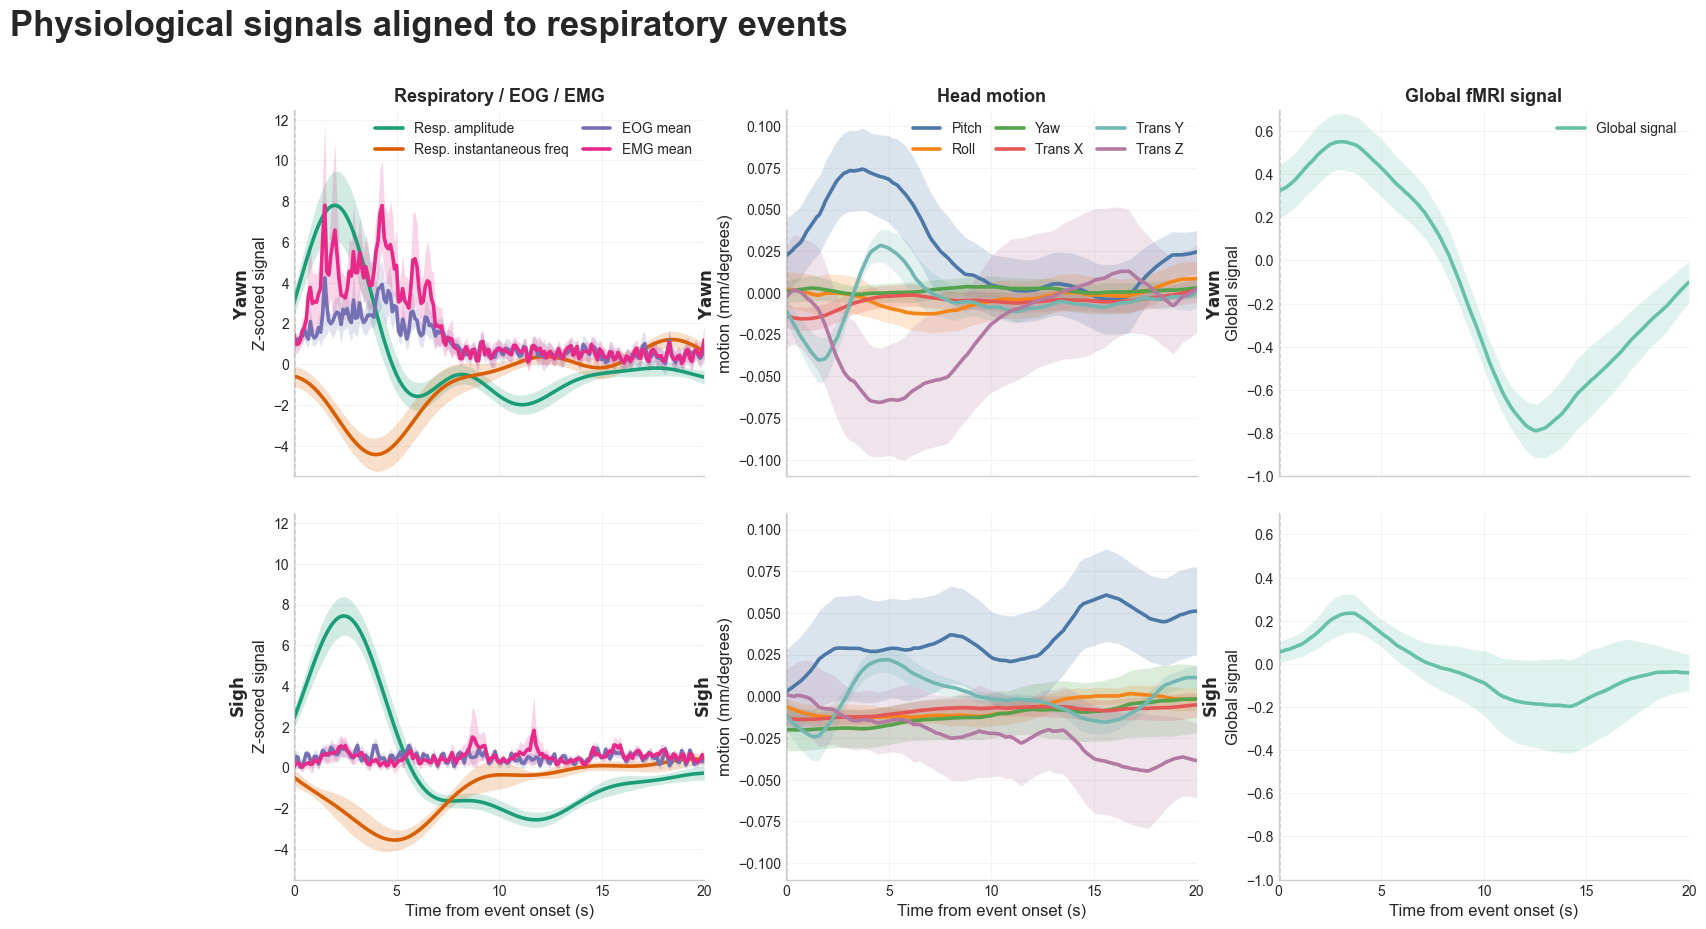

In [9]:
%matplotlib inline

event_groups = ['Yawn', 'Sigh']

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
plt.subplots_adjust(wspace=0.2, hspace=0.1)
fig.suptitle(
    "Physiological signals aligned to respiratory events",
    fontsize=25,
    fontweight="bold",
    x = 0.2
)

for row, event_label in enumerate(event_groups):
    for col, (group_label, specs) in enumerate(signal_groups):
        ax = axes[row, col]

        for signal_label, _, _, color in specs:
            # Extract the bootstrap samples for the current signal and event type
            windows = bootstrap_results_sigh if event_label == 'Sigh' else bootstrap_results_yawn
            windows = [iter_out[group_label][signal_label] for iter_out in windows]  # list of arrays
            windows = np.vstack(windows) if windows else np.empty((0, EVENT_TIME.size), dtype=float)
            # compute the mean window across all bootstrap iterations
            mean_window = _nanmean_axis0(windows)
            # compute the standard deviation window across all bootstrap iterations
            std_window = np.nanstd(windows, axis=0)
            ax.plot(
                EVENT_TIME,
                mean_window,
                color=color,
                linewidth=2.6,
                label=signal_label,
            )
            ax.fill_between(
                EVENT_TIME,
                mean_window - std_window,
                mean_window + std_window,
                color=color,
                alpha=0.2,
                linewidth=0.0,
            )

        ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
        ax.set_xlim(0.0, EVENT_DUR)
        ax.set_xticks(np.arange(0.0, EVENT_DUR + 0.1, 5.0))
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row == 0:
            ax.set_title(group_label, fontsize=13, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"$\\bf{{{event_label}}}$ \nZ-scored signal", fontsize=12)
            ax.set_ylim(-5.5, 12.5)
        if col == 1:
            ax.set_ylabel(f"$\\bf{{{event_label}}}$ \nmotion (mm/degrees)", fontsize=12)
            ax.set_ylim(-0.11, 0.11)
        if col == 2:
            ax.set_ylabel(f"$\\bf{{{event_label}}}$ \nGlobal signal", fontsize=12)
            ax.set_ylim(-1.0, 0.7)
        if row == 1:
            ax.set_xlabel("Time from event onset (s)", fontsize=12)

        if row == 0:
            legend_ncol = 2 if col == 0 else 3
            ax.legend(
                loc="upper right",
                frameon=False,
                fontsize=10.0,
                ncol=legend_ncol,
                handlelength=2.0,
                columnspacing=1.0,
            )

plt.show()
